####Setup

In [ ]:
!pip -q install sumy transformers==4.43.3 sentencepiece evaluate rouge_score sacrebleu bert_score nltk


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.3/97.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 95.9 MB/s eta 0:00:00


In [ ]:
!pip -q install --upgrade nltk

In [ ]:
import re,sys,types
import pandas as pd
import os, json,itertools
import numpy as np
import torch
import nltk


In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
from typing import List, Dict, Any, Tuple
from collections import defaultdict, Counter

from transformers import PegasusForConditionalGeneration, PegasusTokenizer

import evaluate


In [ ]:
import json
from google.colab import files
uploaded = files.upload()

Saving CUAD_v1.json to CUAD_v1.json


####Text cleaning

In [ ]:
def clean_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = re.sub(r"-\n\s*", "", s)       # de-hyphenation at EOL
    s = re.sub(r"\n{2,}", "\n\n", s)   # collapse blank lines
    s = re.sub(r"[ \t]+", " ", s)      # collapse spaces/tabs
    return s.strip()

In [ ]:
#Building contract_df from CUAD-style JSON
def build_contracts_df_from_json(contracts_json: List[dict]) -> pd.DataFrame:
    rows = []
    for c in contracts_json:
        cid = c.get("title") or c.get("contract_id") or "UNKNOWN_ID"
        paragraphs = [p.get("context", "") for p in c.get("paragraphs", [])]
        rows.append({"contract_id": cid, "full_text": "\n".join(paragraphs)})
    return pd.DataFrame(rows)

###---- 2) TextRank (extractive) ----

In [ ]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.summarizers.text_rank import TextRankSummarizer
from sumy.nlp.tokenizers import Tokenizer

In [ ]:
import nltk
nltk.download('punkt', quiet=True)
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
  nltk.download('punkt_tab', quiet=True);

In [ ]:
def textrank_summary_safe(text: str, num_sentences: int = 12) -> str:
    try:
        parser = PlaintextParser.from_string(text or "", Tokenizer("english"))
        summarizer = TextRankSummarizer()
        n = max(1, min(num_sentences, len(list(parser.document.sentences))))
        summary = summarizer(parser.document, n)
        return " ".join(str(s) for s in summary)
    except Exception as e:
        return f"Error(TextRank): {e}"

In [ ]:
import os, json
if os.path.exists("CUAD_v1.json"):
    with open("CUAD_v1.json", "r") as f:
        data = json.load(f)["data"]
    contexts = [p.get("context","") for c in data for p in c.get("paragraphs",[])]
else:
    raise RuntimeError("No contexts found. Define a list `contexts` or place CUAD_v1.json in this folder.")

In [ ]:
import pandas as pd
extractive_summaries = [textrank_summary_safe(t, 12) for t in contexts]

In [ ]:
df_extractive_summaries = pd.DataFrame({
    "context": contexts,
    "extractive_summary": extractive_summaries
})

In [ ]:
# Persist to disk
df_extractive_summaries.to_csv("extractive_textrank.csv", index=False)

In [ ]:
df_extractive_summaries.head()

,context,extractive_summary
0,EXHIBIT 10.6\n\n ...,Distributor shall make re...
1,Exhibit 10.26 CONFIDENTIAL TREATMENT HAS BE...,Subject to the terms and conditions of this Ag...
2,Exhibit 10.16 SUPPLY CONTRACT Contract No: Dat...,The agreement and order 2.1 During the validit...
3,1 ...,"As used in this Agreement, the term ""Web site""..."
4,Exhibit 1\n\nJOINT FILING AGREEMENT\n\nThe und...,Exhibit 1 The undersigned hereby agree to join...


### ---- 3) Pegasus (abstractive) ----


In [ ]:
from transformers import PegasusTokenizer, PegasusForConditionalGeneration
from datasets import load_dataset


In [ ]:
# 2️ Load Legal-Pegasus model & tokenizer
model_name = "nsi319/legal-pegasus"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
tokenizer = PegasusTokenizer.from_pretrained(model_name)
model = PegasusForConditionalGeneration.from_pretrained(model_name).to("cuda")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

In [ ]:
def extract_paragraph_contexts(data):
    results = []
    for contract in data:
        for paragraph in contract['paragraphs']:
            results.append(paragraph['context'])
    return results
with open("CUAD_v1.json", "r") as f:
    data = json.load(f)["data"]


In [ ]:
contexts = extract_paragraph_contexts(data)
print(len(contexts), "paragraphs extracted")
print(contexts[0][:300])  # first 300 chars of first context


510 paragraphs extracted
EXHIBIT 10.6

                              DISTRIBUTOR AGREEMENT

         THIS  DISTRIBUTOR  AGREEMENT (the  "Agreement")  is made by and between Electric City Corp.,  a Delaware  corporation  ("Company")  and Electric City of Illinois LLC ("Distributor") this 7th day of September, 1999.

        


In [ ]:
def clean_text(s: str) -> str:
    if not isinstance(s, str): return ""
    s = re.sub(r"-\n\s*", "", s)     # remove hyphenation
    s = re.sub(r"\n{2,}", "\n\n", s) # collapse blank lines
    s = re.sub(r"[ \t]+", " ", s)    # collapse spaces/tabs
    return s.strip()

cleaned_contexts = [clean_text(c) for c in contexts]

In [ ]:
def load_cuad_contexts(cuad_path: str = "CUAD_v1.json") -> List[str]:
    """Return list of paragraph texts from CUAD JSON."""
    with open(cuad_path, "r", encoding="utf-8") as f:
        data = json.load(f)["data"]
    return [p.get("context", "") for c in data for p in c.get("paragraphs", [])]

In [ ]:
def chunk_text(text: str, max_tokens: int = 512, overlap: int = 64) -> List[str]:
    # simple token-based sliding window
    enc = tokenizer(text, return_tensors=None, truncation=False)
    ids = enc["input_ids"]
    chunks = []
    i = 0
    while i < len(ids):
        chunk_ids = ids[i:i+max_tokens]
        chunks.append(tokenizer.decode(chunk_ids, skip_special_tokens=True))
        if i + max_tokens >= len(ids): break
        i += max_tokens - overlap
    return chunks or [""]

In [ ]:
def summarize_batch(texts, max_input_length=512, max_target_length=128):
    inputs = tokenizer(
        texts,
        max_length=max_input_length,
        truncation=True,
        return_tensors="pt",
        padding=True
    ).to("cuda")

    with torch.no_grad():
        summary_ids = model.generate(
            **inputs,
            max_length=max_target_length,
            min_length=30,
            length_penalty=2.0,
            num_beams=4,
            early_stopping=True
        )

    return [tokenizer.decode(g, skip_special_tokens=True, clean_up_tokenization_spaces=True) for g in summary_ids]

In [ ]:
batch_size = 1
pegasus_summaries = []

for i in range(0, len(cleaned_contexts), batch_size):
    batch_texts = cleaned_contexts[i:i+batch_size]
    summaries = summarize_batch(batch_texts)
    pegasus_summaries.extend(summaries)



In [ ]:
assert len(pegasus_summaries) == len(contexts), "Length mismatch: contexts vs pegasus_summaries"

In [ ]:
# If df_summaries already exists with "context"
df_summaries = pd.DataFrame({
    "context": contexts,
    "pegasus_summary": pegasus_summaries
})

In [ ]:
df_summaries.to_csv("abstractive_pegasus.csv", index=False)
print("Saved -> abstractive_pegasus.csv")

Saved -> abstractive_pegasus.csv


In [ ]:
df_summaries.head()

,context,pegasus_summary
0,EXHIBIT 10.6\n\n ...,"On September 7, 1999, Electric City Corp., a D..."
1,Exhibit 10.26 CONFIDENTIAL TREATMENT HAS BE...,"On August 1, 2011, the Securities and Exchange..."
2,Exhibit 10.16 SUPPLY CONTRACT Contract No: Dat...,The buyer entrusts SHENZHEN YICHANGTAI IMPORT ...
3,1 ...,"On April 6, 1999, Centrack International, a Fl..."
4,Exhibit 1\n\nJOINT FILING AGREEMENT\n\nThe und...,"On March 27, 2020, Shelby J. Butterfield signe..."


##Hybrid Summarisation

In [ ]:
import os, re, json, hashlib, unicodedata, string
import numpy as np, pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel


In [ ]:
PATH_E = "extractive_textrank.csv"
PATH_A = "abstractive_pegasus.csv"
CUAD_JSON = "CUAD_v1.json"

In [ ]:
# Outputs
OUT_MERGED_CSV = "summaries_hybrid.csv"
OUT_SBERT_ROWS = "sbert_paragraph_eval_rows.csv"
OUT_SBERT_SUMM = "sbert_paragraph_eval_summary.csv"
OUT_SBERT_UPGR = "sbert_eval_hybrids_upgraded.csv"

In [ ]:
USE_SENTENCE_TRANSFORMERS = False   # set True if you prefer SentenceTransformer API


In [ ]:
# Thresholds / Budgets
TAU = 0.6
SENT_BUDGET = 18
LOW_RECALL_THRESH = 0.50
MMR_LAMBDAS = [0.60, 0.65, 0.70]
BASE = 4       # dynamic k base
SLOPE = 0.05   # dynamic k slope per ref sentence
CAP = 10       # dynamic k upper cap

In [ ]:
# Pegasus polishing toggle
PEGASUS_ON_LOW_RECALL = True
PEGASUS_MODEL = "nsi319/legal-pegasus"

In [ ]:
# Display (optional)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", None)

In [ ]:
def normalize_context(s: str) -> str:
    s = unicodedata.normalize("NFKC", s or "")
    s = re.sub(r"\s+", " ", s).strip().lower()
    return s

In [ ]:
def make_keys(df, ctx_col="context"):
    df["key_text"] = df[ctx_col].map(normalize_context)
    df["key_hash"] = df["key_text"].map(lambda t: hashlib.sha1(t.encode("utf-8")).hexdigest())
    return df

In [ ]:
_SENT_SPLIT = re.compile(r'(?<=[\.\?\!;])\s+|\n+')
def split_sents(text):
    toks = [t.strip() for t in _SENT_SPLIT.split(str(text or "")) if t and t.strip()]
    return toks

In [ ]:
def clip_to_sentence_budget(text, max_sents=SENT_BUDGET):
    sents = split_sents(text)
    return " ".join(sents[:max_sents])

In [ ]:
def dyn_k(len_ref, base=BASE, slope=SLOPE, cap=CAP):
    return int(min(cap, base + slope * len_ref))

In [ ]:
def _safe_sent_tokenize_fallback(s: str):
    return re.split(r'(?<=[.!?])\s+', s or "")

In [ ]:
def split_sents_loose(s: str):
    try:
        import nltk
        return nltk.sent_tokenize(s or "")
    except Exception:
        return _safe_sent_tokenize_fallback(s)

In [ ]:
def blend_and_dedup(extractive: str, abstractive: str, sentence_budget: int = SENT_BUDGET) -> str:
    ext_sents = split_sents_loose(extractive or "")
    abs_sents = split_sents_loose(abstractive or "")
    all_sents = ext_sents + abs_sents
    seen, out = set(), []
    for s in all_sents:
        key = re.sub(r"\s+", " ", (s or "").strip().lower())
        if key and key not in seen and len(key.split()) >= 4:
            seen.add(key); out.append(s)
        if len(out) >= sentence_budget:
            break
    return " ".join(out)


####CUAD Builders(refs, lables, answers, category refs)

In [ ]:
def get_cat_name(qa):
    if "id" in qa and "__" in qa["id"]:
        return qa["id"].split("__")[-1]
    q = qa.get("question","").strip()
    return re.sub(r"[:\?\.\s]+$", "", q) or "UNKNOWN"

In [ ]:

def build_refs_labels_answers(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        j = json.load(f)
    rows = []
    for c in j["data"]:
        for p in c["paragraphs"]:
            ctx = p["context"]
            key_text = normalize_context(ctx)
            spans, labels, answers = [], [], {}
            for qa in p.get("qas", []):
                if qa.get("is_impossible"):
                    continue
                qid = qa.get("id","")
                lab = qid.split("__")[-1] if "__" in qid else qa.get("question","").strip()
                labels.append(lab)
                for a in qa.get("answers", []):
                    t = (a.get("text") or "").strip()
                    if t:
                        spans.append(t)
                        answers.setdefault(lab, set()).add(t)
            if spans:
                rows.append({
                    "key_text": key_text,
                    "ref_text": " | ".join(list(dict.fromkeys(spans))),
                    "labels": sorted(set(labels)),
                    "answers": {k: sorted(v) for k,v in answers.items()}
                })
    out = pd.DataFrame(rows).drop_duplicates("key_text")
    out["key_hash"] = out["key_text"].map(lambda t: hashlib.sha1(t.encode("utf-8")).hexdigest())
    return out

In [ ]:
def build_cat_refs_from_cuad(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        j = json.load(f)
    rows = []
    for c in j["data"]:
        for p in c["paragraphs"]:
            key = normalize_context(p["context"])
            bucket = {}
            for qa in p.get("qas", []):
                if qa.get("is_impossible"):
                    continue
                cat = get_cat_name(qa)
                for a in qa.get("answers", []):
                    t = (a.get("text") or "").strip()
                    if not t:
                        continue
                    bucket.setdefault(cat, []).append(t)
            if bucket:
                # de-dup inside each category
                bucket = {k: " | ".join(dict.fromkeys(v)) for k,v in bucket.items()}
                rows.append({"key_text": key, "cat_refs": bucket})
    df = pd.DataFrame(rows).drop_duplicates("key_text")
    df["key_hash"] = df["key_text"].map(lambda t: hashlib.sha1(t.encode("utf-8")).hexdigest())
    return df


##### Lexical evaluation helpers (label coverage, answer EM/F1)


In [ ]:
def norm_text(x):
    x = str(x or "").lower()
    x = x.translate(str.maketrans("","",string.punctuation))
    x = re.sub(r"\s+"," ", x).strip()
    return x

In [ ]:
def label_coverage(summary, labels):
    if not labels: return np.nan
    s = (summary or "").lower()
    hits = 0
    for lab in labels:
        t = str(lab or "").lower()
        if any(v in s for v in {t, t.replace("-"," "), t.replace(" ","")}):
            hits += 1
    return hits/len(labels)

In [ ]:
def best_em_f1(ans_list, summary):
    if not ans_list: return (np.nan, np.nan)
    s = norm_text(summary)
    ems,f1s = [],[]
    for a in ans_list:
        a_norm = norm_text(a)
        ems.append(1.0 if a_norm in s else 0.0)
        at, st = set(a_norm.split()), set(s.split())
        inter = len(at & st)
        prec = inter/max(1,len(st)); rec = inter/max(1,len(at))
        f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
        f1s.append(f1)
    return (max(ems), max(f1s))

####SBERT-style embeddings and alignment (Transformers default)

In [ ]:
from functools import lru_cache
import torch

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
if USE_SENTENCE_TRANSFORMERS:
    # Optional path if you insist on sentence-transformers
    from sentence_transformers import SentenceTransformer
    ST_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
    st_model = SentenceTransformer(ST_MODEL_NAME, device=device)
    def encode_sentences(sentences, model=None, tokenizer=None, device=device, batch_size=32, max_length=512):
        return st_model.encode(sentences, batch_size=batch_size, show_progress_bar=False, normalize_embeddings=True)
else:
    tok = AutoTokenizer.from_pretrained("sentence-transformers/all-mpnet-base-v2")
    mdl = AutoModel.from_pretrained("sentence-transformers/all-mpnet-base-v2").to(device)
    def encode_sentences(sentences, model=mdl, tokenizer=tok, device=device, batch_size=32, max_length=512):
        embs = []
        model.eval()
        with torch.no_grad():
            for i in range(0, len(sentences), batch_size):
                batch = sentences[i:i+batch_size]
                enc = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
                out = model(**enc)                                  # last_hidden_state [B, T, H]
                attn = enc["attention_mask"].unsqueeze(-1).float()  # [B, T, 1]
                summed  = (out.last_hidden_state * attn).sum(dim=1)  # [B, H]
                counts = attn.sum(dim=1).clamp(min=1e-9)             # [B, 1]
                mean_pooled = summed / counts                        # [B, H]
                mean_pooled = torch.nn.functional.normalize(mean_pooled, p=2, dim=1)
                embs.append(mean_pooled.cpu())
        return torch.cat(embs, dim=0).numpy()

In [ ]:
def sbert_sentence_alignment_transformers(model, tokenizer, summary, reference,
                                          device=device, taus=(0.5,0.6,0.7), batch_size=32):
    S = split_sents(summary)
    R_sents = split_sents(reference)
    if not S or not R_sents:
        return {
            "len_sum": len(S), "len_ref": len(R_sents),
            "P@0.6": np.nan, "R@0.6": np.nan, "F1@0.6": np.nan,
            "P@avg": np.nan, "R@avg": np.nan, "F1@avg": np.nan,
            "mean_max_sim_sum": np.nan, "mean_max_sim_ref": np.nan
        }
    Es = encode_sentences(S)
    Er = encode_sentences(R_sents)
    sims = Es @ Er.T
    max_s = sims.max(axis=1)
    max_r = sims.max(axis=0)
    out = {
        "len_sum": len(S),
        "len_ref": len(R_sents),
        "mean_max_sim_sum": float(max_s.mean()),
        "mean_max_sim_ref": float(max_r.mean()),
    }
    Ps, Rs, F1s = [], [], []
    for tau in taus:
        prec = float((max_s >= tau).sum()) / len(S)
        rec  = float((max_r >= tau).sum()) / len(R_sents)
        f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
        out[f"P@{tau}"]  = prec
        out[f"R@{tau}"]  = rec
        out[f"F1@{tau}"] = f1
        Ps.append(prec); Rs.append(rec); F1s.append(f1)
    out["P@avg"]  = float(np.mean(Ps))
    out["R@avg"]  = float(np.mean(Rs))
    out["F1@avg"] = float(np.mean(F1s))
    return out

####MMR selector (relevance to ref centroid vs redundancy)

In [ ]:
def mmr_select(cands_text, ref_text, k=6, lam=0.65):
    C = split_sents(cands_text)
    R = split_sents(ref_text)
    if not C: return []
    Ec = encode_sentences(C)
    Er = encode_sentences(R) if R else None
    ref_centroid = Er.mean(axis=0, keepdims=True) if Er is not None else None
    rel = (Ec @ ref_centroid.T).ravel() if ref_centroid is not None else np.zeros(len(C))
    selected, remaining = [], list(range(len(C)))
    while remaining and len(selected) < k:
        if not selected:
            idx = int(np.argmax(rel))
            selected.append(idx); remaining.remove(idx); continue
        Es = Ec[selected]
        red = (Ec[remaining] @ Es.T).max(axis=1)
        score = lam*rel[remaining] - (1-lam)*red
        idx = remaining[int(np.argmax(score))]
        selected.append(idx); remaining.remove(idx)
    return [C[i] for i in selected]

####SBERT-guided augmentation (borrow from extractive to cover uncovered refs)

In [ ]:
def augment_hybrid_with_extractive(summary, extractive, ref_text,
                                   model=None, tokenizer=None, device=device,
                                   tau=0.6, max_add=2, sim_dup=0.80):
    S = split_sents(summary); E = split_sents(extractive); R = split_sents(ref_text)
    if not R or not E:
        return summary or extractive
    Es = encode_sentences(S) if len(S) else None
    Ee = encode_sentences(E)
    Er = encode_sentences(R)
    if Es is not None:
        sims_SR = Es @ Er.T
        ref_covered = sims_SR.max(axis=0) >= tau
        ref_max_sim = sims_SR.max(axis=0)
    else:
        ref_covered = np.zeros(len(R), dtype=bool)
        ref_max_sim = np.zeros(len(R))
    sims_ER = Ee @ Er.T
    to_add = []; added_lower = set()
    for ridx in np.argsort(ref_max_sim):  # worst-covered first
        if ref_covered[ridx]:
            continue
        if len(to_add) >= max_add:
            break
        best_e = int(np.argmax(sims_ER[:, ridx]))
        cand = E[best_e].strip()
        if not cand:
            continue
        cand_l = cand.lower()
        if any(cand_l == s.lower() for s in S) or cand_l in added_lower:
            continue
        if Es is not None:
            cand_emb = encode_sentences([cand])
            if float((cand_emb @ Es.T).max()) >= sim_dup:
                continue
        to_add.append(cand); added_lower.add(cand_l)
    if not to_add:
        return summary
    out = (summary or "").strip()
    for s in to_add:
        if out and not out.endswith((".", "!", "?")): out += "."
        out += (" " if out else "") + s
    return out


####Category-aware patcher (ensure coverage for categories present in this paragraph)

In [ ]:
def ensure_category_coverage(summary, extractive, cat_refs,
                             model=None, tokenizer=None, device=device,
                             tau=0.6, max_total_add=3, sim_dup=0.80):
    S = split_sents(summary); E = split_sents(extractive)
    if not cat_refs:
        return summary
    Es = encode_sentences(S) if S else None
    Ee = encode_sentences(E) if E else None
    to_add = []; added_l = set(); added_count = 0
    for cat, ref_text in cat_refs.items():
        if added_count >= max_total_add:
            break
        R = split_sents(ref_text)
        if not R:
            continue
        Er = encode_sentences(R)
        covered = False
        if Es is not None:
            sims_SR = Es @ Er.T
            covered = bool(sims_SR.max() >= tau)
        if covered or Ee is None:
            continue
        sims_ER = Ee @ Er.T
        best_e = int(np.argmax(sims_ER.max(axis=1)))
        cand = E[best_e].strip()
        if not cand:
            continue
        cand_l = cand.lower()
        if cand_l in added_l or any(cand_l == s.lower() for s in S):
            continue
        if Es is not None:
            cand_emb = encode_sentences([cand])
            if float((cand_emb @ Es.T).max()) >= sim_dup:
                continue
        to_add.append(cand); added_l.add(cand_l); added_count += 1
    if not to_add:
        return summary
    out = (summary or "").strip()
    for s in to_add:
        if out and not out.endswith((".", "!", "?")): out += "."
        out += (" " if out else "") + s
    return out

####Load & align

In [ ]:
df_e = pd.read_csv(PATH_E)   # needs: context, extractive_summary
df_a = pd.read_csv(PATH_A)   # needs: context, pegasus_summary
assert "context" in df_e.columns and "extractive_summary" in df_e.columns, "df_e must have context, extractive_summary"
assert "context" in df_a.columns and "pegasus_summary" in df_a.columns, "df_a must have context, pegasus_summary"

make_keys(df_e); make_keys(df_a)
df = (df_e[["key_hash","key_text","context","extractive_summary"]]
      .merge(df_a[["key_hash","pegasus_summary"]], on="key_hash", how="inner"))
print(f"Merged rows: {len(df)} (from E:{len(df_e)} A:{len(df_a)})")

Merged rows: 512 (from E:510 A:510)


In [ ]:
refs = build_refs_labels_answers(CUAD_JSON)
cats = build_cat_refs_from_cuad(CUAD_JSON)

df = df.merge(refs[["key_hash","key_text","ref_text","labels","answers"]], on="key_hash", how="left")
df = df.merge(cats[["key_hash","cat_refs"]], on="key_hash", how="left")
df["cat_refs"] = df["cat_refs"].apply(lambda x: x if isinstance(x, dict) else {})

In [ ]:
df = df[df["ref_text"].notna() & (df["ref_text"].str.len()>0)].copy()
df["len_ref"] = df["ref_text"].map(lambda t: len(split_sents(t)))
print("Rows with references:", len(df))

Rows with references: 512


####Baselines

In [ ]:
df["hybrid_blend"] = [
    blend_and_dedup(e, a, sentence_budget=SENT_BUDGET)
    for e, a in zip(df["extractive_summary"].fillna(""), df["pegasus_summary"].fillna(""))
]
df["hybrid_blend"] = df["hybrid_blend"].map(lambda s: clip_to_sentence_budget(s, SENT_BUDGET))

####MMR with dynamic k

In [ ]:
def build_mmr_dynamic_row(row, lam=0.65):
    k = dyn_k(row["len_ref"], base=BASE, slope=SLOPE, cap=CAP)
    picks = mmr_select(row.get("extractive_summary",""), row["ref_text"], k=k, lam=lam)
    return " ".join(picks)

###grid-search lam per row and keep best by SBERT F1 then Recall

In [ ]:
def sbert_cover_score(text, ref):
    res = sbert_sentence_alignment_transformers(None, None, text or "", ref or "", device=device, taus=(TAU,))
    return float(res[f"F1@{TAU}"]), float(res[f"R@{TAU}"]), float(res[f"P@{TAU}"])

In [ ]:
def best_mmr_per_row(row):
    cands = {lam: build_mmr_dynamic_row(row, lam=lam) for lam in MMR_LAMBDAS}
    scored = [(lam,)+sbert_cover_score(txt, row["ref_text"]) for lam, txt in cands.items()]
    best = sorted(scored, key=lambda x: (x[1], x[2]), reverse=True)[0]
    return cands[best[0]]

df["hybrid_mmr_dyn"] = df.apply(best_mmr_per_row, axis=1)

##### Augment with extractive (up to N, based on len_ref)

In [ ]:
def max_add_from_len_ref(len_ref):
    return 1 if len_ref <= 20 else (2 if len_ref <= 50 else 3)

In [ ]:
df["hybrid_aug"] = df.apply(
    lambda r: augment_hybrid_with_extractive(
        r["hybrid_mmr_dyn"], r.get("extractive_summary",""), r["ref_text"],
        device=device, tau=TAU, max_add=max_add_from_len_ref(r["len_ref"]), sim_dup=0.80
    ),
    axis=1
)

In [ ]:
# Category-aware patch
df["hybrid_strong"] = df.apply(
    lambda r: ensure_category_coverage(
        r["hybrid_aug"], r.get("extractive_summary",""), r.get("cat_refs", {}),
        device=device, tau=TAU, max_total_add=3, sim_dup=0.80
    ),
    axis=1
)
df["hybrid_strong"] = df["hybrid_strong"].map(lambda s: clip_to_sentence_budget(s, SENT_BUDGET))

In [ ]:
if PEGASUS_ON_LOW_RECALL:
    from transformers import PegasusTokenizer, PegasusForConditionalGeneration
    peg_tok = PegasusTokenizer.from_pretrained(PEGASUS_MODEL)
    peg_mdl = PegasusForConditionalGeneration.from_pretrained(PEGASUS_MODEL).to(device).eval()

    @torch.inference_mode()
    def pegasus_once(text, max_input_length=512, max_target_length=180, num_beams=4):
        enc = peg_tok([text], max_length=max_input_length, truncation=True, padding=True, return_tensors="pt").to(device)
        gen = peg_mdl.generate(**enc, max_length=max_target_length, min_length=min(60, max_target_length-20),
                               num_beams=num_beams, length_penalty=2.0, early_stopping=True)
        return peg_tok.batch_decode(gen, skip_special_tokens=True, clean_up_tokenization_spaces=True)[0]

    polished = []
    for _, r in df.iterrows():
        f1, recall, _ = sbert_cover_score(r["hybrid_strong"], r["ref_text"])
        if recall < LOW_RECALL_THRESH:
            cand = pegasus_once(r["hybrid_strong"])
            cand = clip_to_sentence_budget(cand, SENT_BUDGET)
            f1_c, _, _ = sbert_cover_score(cand, r["ref_text"])
            polished.append(cand if f1_c > f1 else r["hybrid_strong"])
        else:
            polished.append(r["hybrid_strong"])
    df["hybrid_strong_polished"] = polished


In [ ]:
df.to_csv(OUT_MERGED_CSV, index=False)
print(f"Saved -> {OUT_MERGED_CSV}  (columns now include: context, extractive_summary, pegasus_summary, "
      f"hybrid_blend, hybrid_mmr_dyn, hybrid_aug, hybrid_strong"
      + (", hybrid_strong_polished" if "hybrid_strong_polished" in df.columns else "") + ")")

Saved -> summaries_hybrid.csv  (columns now include: context, extractive_summary, pegasus_summary, hybrid_blend, hybrid_mmr_dyn, hybrid_aug, hybrid_strong, hybrid_strong_polished)


####Evaluation

In [ ]:
systems = [c for c in ["extractive_summary","pegasus_summary","hybrid_blend","hybrid_mmr_dyn","hybrid_aug","hybrid_strong","hybrid_strong_polished"] if c in df.columns]


#### Label coverage + EM/F1 per system


In [ ]:
for sys in systems:
    df[f"{sys}_label_coverage"] = [label_coverage(s, labs) for s,labs in zip(df[sys], df["labels"])]
    emf1 = df.apply(lambda r: (
        np.mean([best_em_f1(spans, r[sys])[0] for spans in (r["answers"] or {}).values()]) if isinstance(r["answers"],dict) else np.nan,
        np.mean([best_em_f1(spans, r[sys])[1] for spans in (r["answers"] or {}).values()]) if isinstance(r["answers"],dict) else np.nan
    ), axis=1, result_type="expand")
    df[f"{sys}_answerEM"], df[f"{sys}_answerF1"] = emf1[0], emf1[1]

##### SBERT per-row stats


In [ ]:
all_rows=[]
for sys in systems:
    stats=[]
    for _, row in df.iterrows():
        res = sbert_sentence_alignment_transformers(None, None, row[sys], row["ref_text"], device=device, taus=(0.5,0.6,0.7))
        res["system"]=sys
        stats.append(res)
    all_rows.append(pd.DataFrame(stats))

out = pd.concat(all_rows, ignore_index=True)
agg = out.groupby("system").agg({
    "F1@0.6":"mean", "P@0.6":"mean", "R@0.6":"mean",
    "F1@avg":"mean", "mean_max_sim_sum":"mean", "mean_max_sim_ref":"mean"
}).reset_index().sort_values("F1@0.6", ascending=False)

print("\n=== SBERT Summary (higher is better) ===")
print(agg.round(3))

out.to_csv(OUT_SBERT_ROWS, index=False)
agg.to_csv(OUT_SBERT_SUMM, index=False)
print(f"Saved: {OUT_SBERT_ROWS}, {OUT_SBERT_SUMM}")



=== SBERT Summary (higher is better) ===
                   system  F1@0.6  P@0.6  R@0.6  F1@avg  mean_max_sim_sum  mean_max_sim_ref
3          hybrid_mmr_dyn   0.684  0.880  0.587   0.654             0.779             0.633
1              hybrid_aug   0.673  0.802  0.607   0.649             0.746             0.646
5  hybrid_strong_polished   0.660  0.748  0.627   0.638             0.720             0.651
4           hybrid_strong   0.657  0.737  0.626   0.637             0.716             0.653
0      extractive_summary   0.582  0.574  0.652   0.575             0.644             0.675
2            hybrid_blend   0.574  0.582  0.626   0.566             0.644             0.660
6         pegasus_summary   0.348  0.600  0.293   0.355             0.622             0.484
Saved: sbert_paragraph_eval_rows.csv, sbert_paragraph_eval_summary.csv


####Upgraded comparison (focusing on coverage-aware set)

In [ ]:
def eval_col(col):
    rows=[]
    for _, r in df.iterrows():
        res = sbert_sentence_alignment_transformers(None, None, r[col], r["ref_text"], device=device, taus=(0.5,0.6,0.7))
        res["system"]=col
        rows.append(res)
    return pd.DataFrame(rows)

systems_to_eval = [c for c in ["hybrid_blend","hybrid_mmr_dyn","hybrid_strong"] if c in df.columns]
report = (pd.concat([eval_col(c) for c in systems_to_eval])
          .groupby("system")
          .agg({"F1@0.6":"mean","P@0.6":"mean","R@0.6":"mean",
                "F1@avg":"mean","mean_max_sim_sum":"mean","mean_max_sim_ref":"mean"})
          .reset_index()
          .sort_values("F1@0.6", ascending=False))
print("\n=== Upgraded Hybrids ===")
print(report.round(3))
report.to_csv(OUT_SBERT_UPGR, index=False)
print(f"Saved: {OUT_SBERT_UPGR}")



=== Upgraded Hybrids ===
           system  F1@0.6  P@0.6  R@0.6  F1@avg  mean_max_sim_sum  mean_max_sim_ref
1  hybrid_mmr_dyn   0.684  0.880  0.587   0.654             0.779             0.633
2   hybrid_strong   0.657  0.737  0.626   0.637             0.716             0.653
0    hybrid_blend   0.574  0.582  0.626   0.566             0.644             0.660
Saved: sbert_eval_hybrids_upgraded.csv


##### Quick preview for sanity


In [ ]:
cols = [c for c in ["context","extractive_summary","pegasus_summary","hybrid_blend","hybrid_mmr_dyn","hybrid_aug","hybrid_strong","hybrid_strong_polished"] if c in df.columns]
def short(s, n=200):
    s = "" if s is None else str(s)
    return s if len(s) <= n else s[:n] + "…"
preview = df[cols].head(3).map(lambda v: short(v, 200))
print("\n=== Preview (first 3 rows, truncated) ===")
print(preview.to_string(index=False))


=== Preview (first 3 rows, truncated) ===
                                                                                                                                                                                                      context                                                                                                                                                                                        extractive_summary                                                                                                                                                                                           pegasus_summary                                                                                                                                                                                              hybrid_blend                                                                                                                                                  

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
''''                   system  F1@0.6  P@0.6  R@0.6  F1@avg  mean_max_sim_sum  mean_max_sim_ref
3          hybrid_mmr_dyn   0.684  0.880  0.587   0.654             0.779             0.633
1              hybrid_aug   0.673  0.802  0.607   0.649             0.746             0.646
5  hybrid_strong_polished   0.660  0.748  0.627   0.638             0.720             0.651
4           hybrid_strong   0.657  0.737  0.626   0.637             0.716             0.653
0      extractive_summary   0.582  0.574  0.652   0.575             0.644             0.675
2            hybrid_blend   0.574  0.582  0.626   0.566             0.644             0.660
6         pegasus_summary   0.348  0.600  0.293   0.355             0.622             0.484''''

In [ ]:
sbert_pr = {
    "hybrid_mmr_dyn":       {"P@0.6": 0.880, "R@0.6": 0.587},
    "hybrid_aug":           {"P@0.6": 0.802, "R@0.6": 0.607},
    "hybrid_strong_polished":{"P@0.6": 0.748, "R@0.6": 0.627},
    "hybrid_strong":        {"P@0.6": 0.737, "R@0.6": 0.626},
    "extractive_summary":   {"P@0.6": 0.574, "R@0.6": 0.652},
    "hybrid_blend":         {"P@0.6": 0.582, "R@0.6": 0.626},
    "pegasus_summary":      {"P@0.6": 0.600, "R@0.6": 0.293},
}

In [ ]:
compression = {
    "extractive_summary": 0.3226465739738618,
    "pegasus_summary":    0.05238089562862376,
    "hybrid_blend":       0.12009479048266761,
}

In [ ]:
df_pr = pd.DataFrame.from_dict(sbert_pr, orient="index").reset_index().rename(columns={"index":"system"})
df_comp = pd.DataFrame([
    {"system": k, "compression": v} for k, v in compression.items()
])

In [ ]:
df_rc = df_pr.merge(df_comp, on="system", how="inner")

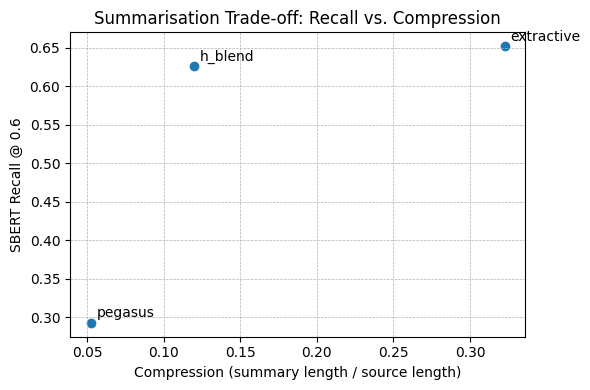

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(df_rc["compression"], df_rc["R@0.6"])

# annotate points
for _, r in df_rc.iterrows():
    plt.annotate(r["system"].replace("_summary","").replace("hybrid_","h_"),
                 (r["compression"], r["R@0.6"]), xytext=(4,4), textcoords="offset points")

plt.xlabel("Compression (summary length / source length)")
plt.ylabel("SBERT Recall @ 0.6")
plt.title("Summarisation Trade-off: Recall vs. Compression")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

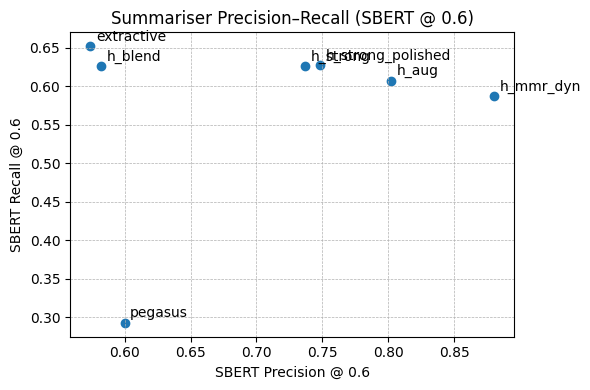

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(df_pr["P@0.6"], df_pr["R@0.6"])

for _, r in df_pr.iterrows():
    plt.annotate(r["system"].replace("_summary","").replace("hybrid_","h_"),
                 (r["P@0.6"], r["R@0.6"]), xytext=(4,4), textcoords="offset points")

plt.xlabel("SBERT Precision @ 0.6")
plt.ylabel("SBERT Recall @ 0.6")
plt.title("Summariser Precision–Recall (SBERT @ 0.6)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

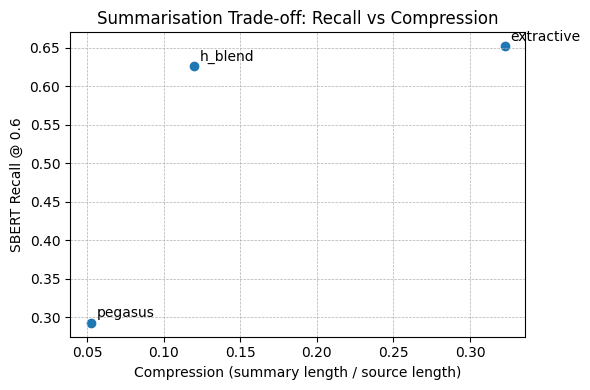

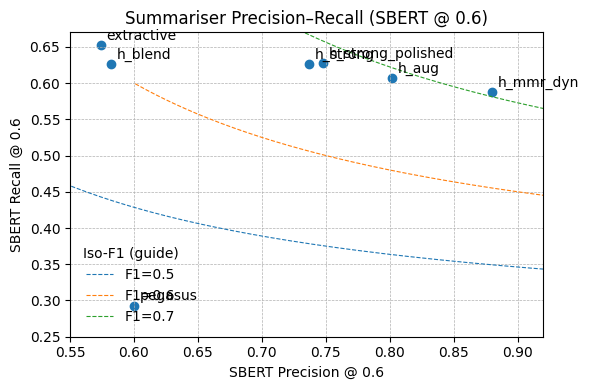

In [ ]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----- YOUR DATA (edit if needed) -----
sbert_pr = {
    "hybrid_mmr_dyn":        {"P@0.6": 0.880, "R@0.6": 0.587},
    "hybrid_aug":            {"P@0.6": 0.802, "R@0.6": 0.607},
    "hybrid_strong_polished":{"P@0.6": 0.748, "R@0.6": 0.627},
    "hybrid_strong":         {"P@0.6": 0.737, "R@0.6": 0.626},
    "extractive_summary":    {"P@0.6": 0.574, "R@0.6": 0.652},
    "hybrid_blend":          {"P@0.6": 0.582, "R@0.6": 0.626},
    "pegasus_summary":       {"P@0.6": 0.600, "R@0.6": 0.293},
}

compression = {
    "extractive_summary": 0.3226465739738618,
    "pegasus_summary":    0.05238089562862376,
    "hybrid_blend":       0.12009479048266761,
}

# Short labels for nicer annotations
nice = {
    "hybrid_mmr_dyn": "h_mmr_dyn",
    "hybrid_aug": "h_aug",
    "hybrid_strong_polished": "h_strong_polished",
    "hybrid_strong": "h_strong",
    "extractive_summary": "extractive",
    "hybrid_blend": "h_blend",
    "pegasus_summary": "pegasus",
}

# ---------- Build frames ----------
df_pr = pd.DataFrame.from_dict(sbert_pr, orient="index").reset_index().rename(columns={"index":"system"})
df_pr["F1@0.6"] = 2*df_pr["P@0.6"]*df_pr["R@0.6"] / (df_pr["P@0.6"] + df_pr["R@0.6"])
df_pr["label"] = df_pr["system"].map(nice)

df_comp = pd.DataFrame([{"system":k,"compression":v} for k,v in compression.items()])
df_rc = df_pr.merge(df_comp, on="system", how="inner")

# ---------- Plot A: Recall vs Compression ----------
plt.figure(figsize=(6,4))
plt.scatter(df_rc["compression"], df_rc["R@0.6"])
for _, r in df_rc.iterrows():
    plt.annotate(r["label"], (r["compression"], r["R@0.6"]), xytext=(4,4), textcoords="offset points")
plt.xlabel("Compression (summary length / source length)")
plt.ylabel("SBERT Recall @ 0.6")
plt.title("Summarisation Trade-off: Recall vs Compression")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.savefig("fig_recall_vs_compression.png", dpi=300)
plt.savefig("fig_recall_vs_compression.pdf")
plt.show()

# ---------- Plot B: Precision–Recall with iso-F1 curves ----------
plt.figure(figsize=(6,4))

# iso-F1 guide curves
for f in [0.5, 0.6, 0.7]:
    P = np.linspace(f+1e-3, 1.0, 200)         # valid range where denominator > 0
    R = (f*P) / (2*P - f)                     # from F1 = 2PR / (P+R)
    R[(2*P - f) <= 0] = np.nan
    plt.plot(P, R, linestyle="--", linewidth=0.8, label=f"F1={f}")

# points
plt.scatter(df_pr["P@0.6"], df_pr["R@0.6"])
for _, r in df_pr.iterrows():
    plt.annotate(r["label"], (r["P@0.6"], r["R@0.6"]), xytext=(4,4), textcoords="offset points")

plt.xlim(0.55, 0.92)   # tweak to your taste
plt.ylim(0.25, 0.67)
plt.xlabel("SBERT Precision @ 0.6")
plt.ylabel("SBERT Recall @ 0.6")
plt.title("Summariser Precision–Recall (SBERT @ 0.6)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend(title="Iso-F1 (guide)", loc="lower left", frameon=False)
plt.tight_layout()
plt.savefig("fig_precision_recall_scatter.png", dpi=300)
plt.savefig("fig_precision_recall_scatter.pdf")
plt.show()
